In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [3]:
image_dir = "/Users/jonathanzhu/nematostella_videos/imgs/"
os.listdir(image_dir)

['wt_16C_3_dpf_03_27_2026_celldish',
 '.DS_Store',
 'rpa_aa_25C_8_dpf_celldish_04_01_2026',
 'glw_ac_25C_2_dpf_03_26_2026',
 'rpa_aa_16C_5_dpf_fert_04_24_2026',
 'wt_25C_8_dpf_celldish_04_01_2026',
 'rpa_bb_16C_8_dpf_celldish_04_01_2026',
 'wt_16c_4_dpf_fert_04_10_2026',
 'glw_ac_25c_3_dpf_fert_04_24_2026',
 'rpa_bb_25C_6_dpf_fert_04_24_2026',
 'rpa_bb_25C_6_dpf_fert_04_10_2026',
 'glw_ac_25c_7_dpf_fert_04_10_2026',
 'rpa_aa_25C_6_dpf_fert_04_10_2026',
 'rpa_aa_16C_6_dpf_movedtodish_03_30_2026',
 'rpa_aa_16C_5_dpf_fert_04_10_2026',
 'wt_25c_3_dpf_fert_04_24_2026',
 'glw_ac_16c_4_dpf_fert_04_10_2026']

In [4]:
#trying some things from a different project I did - does not seem to work but will return to this
#Helper function: For one image, get the boundary regions and the midpoints of the boundary regions
def get_boundary_midpoint(image_path, lower_threshold = 127, upper_threshold = 255):
    #read the image
    img = cv2.imread(image_path, 0)
    #get the boundary regions
    boundary = get_boundary(img, lower_threshold, upper_threshold)
    #get the midpoints of the boundary regions
    midpoints = get_midpoints(boundary)
    return boundary, midpoints

#Helper function: For one image, get the boundary regions
def get_boundary(img, lower_threshold, upper_threshold):
    #threshold the image
    ret,thresh1 = cv2.threshold(img,lower_threshold, upper_threshold ,cv2.THRESH_BINARY)
    #find contours
    contours, hierarchy = cv2.findContours(thresh1, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    #get the boundary regions
    boundary = []
    for contour in contours:
        x,y,w,h = cv2.boundingRect(contour)
        boundary.append((x,y,w,h))
    return boundary

#Helper function: For one image, get the midpoints of the boundary regions
def get_midpoints(boundary):
    midpoints = []
    for x,y,w,h in boundary:
        midpoints.append((x+w//2, y+h//2))
    return midpoints

#helper function: edge detection
#using a simple 3x3 kernel for edge detection
def edge_detection(img, kernel = np.array([[1,1,1],[1,-8,1],[1,1,1]])):
    #for every 3x3 region, element-wise multiplication with the kernel
    #and sum the results to get the edge detection result
    edge = np.zeros_like(img)
    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            edge[i,j] = np.sum(img[i-1:i+2, j-1:j+2]*kernel)
    return edge

#helper function: plot the boundary regions and midpoints
def plot_boundary_midpoint(img, boundary, midpoints):
    fig, ax = plt.subplots()
    ax.imshow(img, cmap='gray')
    for x,y,w,h in boundary:
        rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    for x,y in midpoints:
        ax.scatter(x, y, c='r', s=10)
    plt.show()

def add_midpoints(img, midpoints, n = 10):
    #make a combined image with the midpoints
    img_midpoints = img.copy()
    for x,y in midpoints:
        #in a nxn region around the midpoint, set the pixel values to 255
        #to make the midpoint more visible
        img_midpoints[y-n:y+n, x-n:x+n] = 255
    return img_midpoints

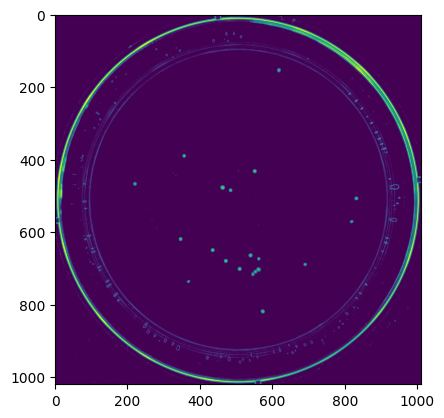

In [5]:
img = mpimg.imread(image_dir + "wt_16C_3_dpf_03_27_2026_celldish/wt_16C_3_dpf_03_27_2026_celldish0001.png")
plt.imshow(img)

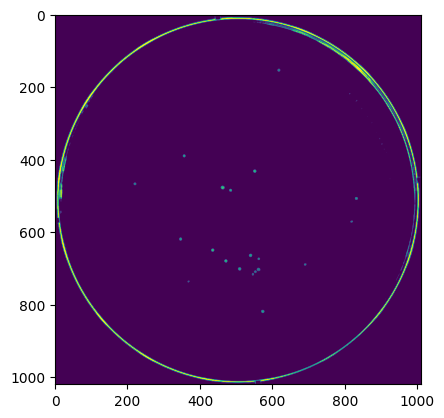

In [10]:
plt.imshow(np.minimum(0.8, np.maximum(0.5, img)))